<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/01_task1_scratch_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### Task 1.3 - Training from Scratch (with seed 640)

**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

This notebook is has the same process as [01_task1_scratch.ipynb](https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/01_task1_scratch.ipynb) and [01_task1_scratch_2.ipynb](https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/01_task1_scratch_2.ipynb) with only the difference being the random seed set. Which for this notebook the seed is 640.

In this notebook, a classification model is trained from scratch, using the dataset [Animals-10](https://www.kaggle.com/datasets/alessiocorrado99/animals10) and the data split analised in the previous notebook ([00_data_exploration.ipynb](https://github.com/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/00_data_exploration.ipynb)). The training is performed independantly over different fractions of the training database (10%, 25%, 50%, 75% and 100%), and the summary of metrics and plots are shown and downloaded in a zip format.

**Observation:**

1.   The first six (6) cells of code bellow were implemented to be able to run the notebook using Google Colab mantainig it connected to the GitHub project. The rest o the code was initially wroten using DataSpell.
2.   This notebook demanded around 5 hours to ran completly, it can be interesting to break the for loop in cell 7 to run each fraction of tha training data independently.

In [1]:
!rm -rf /content/TOL506M_Final_Project

In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# Always clone fresh in Colab
subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")


In [3]:
import sys
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
from torchvision import datasets, transforms

project_root = Path.cwd()
if project_root.name != "TOL506M_Final_Project":
    original = project_root
    while project_root.name != "TOL506M_Final_Project" and project_root != project_root.parent:
        project_root = project_root.parent

    if project_root.name == "TOL506M_Final_Project":
        os.chdir(project_root)
        print(f"Changed working directory from {original} to {project_root}")
    else:
        raise RuntimeError(
            "Could not locate the TOL506M_Final_Project root directory. "
            "Please run this notebook/script from within the project tree."
        )
else:
    print(f"Working directory: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Working directory: /content/TOL506M_Final_Project

PyTorch version: 2.9.0+cu126
CUDA available: True


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print(f'Dataset downloaded: {path}\n')

Using Colab cache for faster access to the 'animals10' dataset.
Dataset downloaded: /kaggle/input/animals10



In [5]:
# Import project modules
from config import Config
from data.dataset import (WildlifeDataset, SplitIndices, stratified_split,
                          translate_names, get_data_loaders)
from tasks.task1 import train_from_scratch

data_fractions = Config.DATA_FRACTIONS
train_size = Config.TRAIN_SPLIT
val_size = Config.VAL_SPLIT
test_size = Config.TEST_SPLIT
Config.RANDOM_SEED = 640
random_seed = Config.RANDOM_SEED

data_path = Path(path) / 'raw-img'
Config.DATA_PATH = data_path

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Download and split dataset as previously done on notebook 00_data_exploration
full_dataset = datasets.ImageFolder(root=str(data_path), transform=basic_transform)
dataset_transformed = translate_names(full_dataset)

wildlife = WildlifeDataset(str(data_path), transform=None)
train_idx_base, val_idx_fixed, test_idx_fixed = stratified_split(
    full_dataset,
    train_size=train_size,
    val_size=val_size,
    test_size=test_size,
    random_seed=640
)

fixed = SplitIndices(train=train_idx_base, val=val_idx_fixed, test=test_idx_fixed)

print(f'Total images: {len(wildlife)}')
print(f'Base Train images: {len(train_idx_base)}')
print(f'Validation images: {len(val_idx_fixed)}')
print(f'Test images: {len(test_idx_fixed)}')

Total images: 26179
Base Train images: 18325
Validation images: 3927
Test images: 3927


In [6]:
# Create output dirs if they don't exist
Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
Config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
Config.METRICS_DIR.mkdir(parents=True, exist_ok=True)


Starting training for data fraction = 10%

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.66it/s]



 Epoch 1/100:
 Train Loss: 3.3279, Train Acc: 15.78%
 Val Loss: 8.0799, Val Acc: 10.01%
Saved best model (Val Acc: 10.01%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.10.pth.


Validation: 100%|██████████| 62/62 [00:07<00:00,  7.87it/s]



 Epoch 2/100:
 Train Loss: 2.2071, Train Acc: 20.03%
 Val Loss: 2.1735, Val Acc: 22.59%
Saved best model (Val Acc: 22.59%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.10.pth.


...

Validation: 100%|██████████| 62/62 [00:07<00:00,  7.87it/s]



 Epoch 60/100:
 Train Loss: 1.2427, Train Acc: 57.10%
 Val Loss: 1.5591, Val Acc: 47.36%


Validation: 100%|██████████| 62/62 [00:07<00:00,  7.90it/s]


 Epoch 61/100:
 Train Loss: 1.2720, Train Acc: 56.28%
 Val Loss: 1.8038, Val Acc: 45.15%
Early stopping triggered at epoch 61.
Training completed in 1029.63 seconds.



 Test Results: 
 Accuracy: 45.73%
 Precision: 52.14%
 Recall: 45.73%
 F1-score: 42.92%


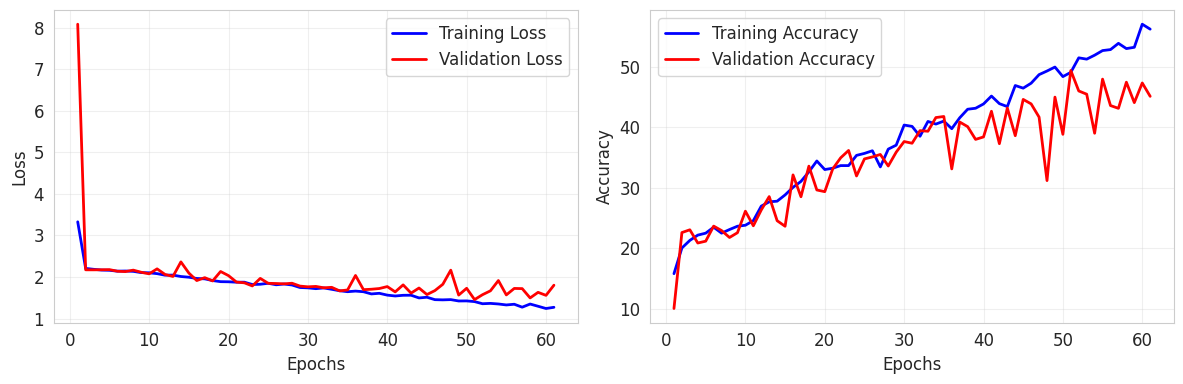

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.10.json

Starting training for data fraction = 25%

Training on 10 classes.
Training samples: 4581.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.55it/s]



 Epoch 1/100:
 Train Loss: 2.4654, Train Acc: 20.21%
 Val Loss: 2.1991, Val Acc: 19.96%
Saved best model (Val Acc: 19.96%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.25.pth.


Validation: 100%|██████████| 62/62 [00:07<00:00,  7.92it/s]



 Epoch 2/100:
 Train Loss: 2.1731, Train Acc: 22.96%
 Val Loss: 2.1556, Val Acc: 21.77%
Saved best model (Val Acc: 21.77%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.25.pth.


...

Validation: 100%|██████████| 62/62 [00:07<00:00,  7.85it/s]



 Epoch 99/100:
 Train Loss: 0.1447, Train Acc: 96.03%
 Val Loss: 0.8651, Val Acc: 75.94%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.72it/s]


 Epoch 100/100:
 Train Loss: 0.1476, Train Acc: 95.59%
 Val Loss: 0.8694, Val Acc: 76.06%
Training completed in 3035.50 seconds.



 Test Results: 
 Accuracy: 76.50%
 Precision: 76.64%
 Recall: 76.50%
 F1-score: 76.35%


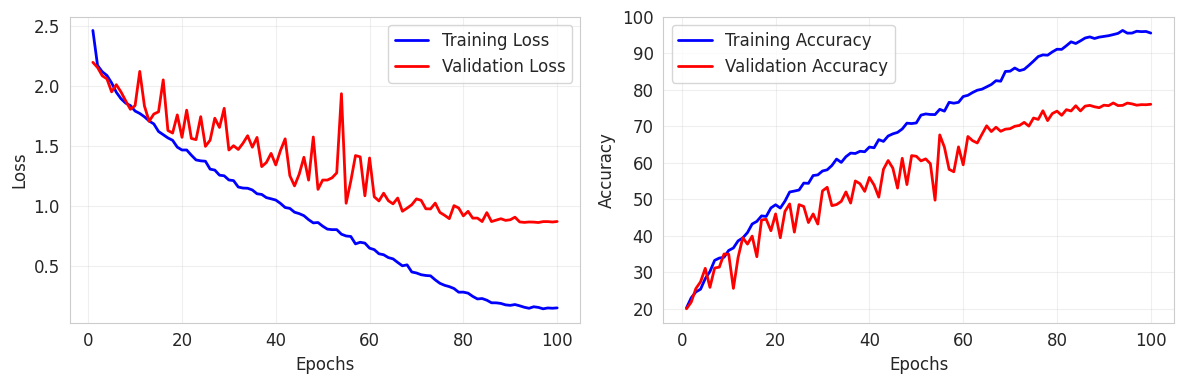

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.25.json

Starting training for data fraction = 50%

Training on 10 classes.
Training samples: 9162.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.70it/s]



 Epoch 1/100:
 Train Loss: 2.3047, Train Acc: 19.52%
 Val Loss: 2.2131, Val Acc: 20.19%
Saved best model (Val Acc: 20.19%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.50.pth.


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.74it/s]



 Epoch 2/100:
 Train Loss: 2.1412, Train Acc: 24.24%
 Val Loss: 2.1215, Val Acc: 24.06%
Saved best model (Val Acc: 24.06%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.50.pth.


...

Validation: 100%|██████████| 62/62 [00:07<00:00,  7.88it/s]



 Epoch 95/100:
 Train Loss: 0.0333, Train Acc: 99.20%
 Val Loss: 0.6153, Val Acc: 84.39%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.73it/s]


 Epoch 96/100:
 Train Loss: 0.0305, Train Acc: 99.44%
 Val Loss: 0.6177, Val Acc: 84.29%
Early stopping triggered at epoch 96.
Training completed in 5052.59 seconds.



 Test Results: 
 Accuracy: 84.36%
 Precision: 84.51%
 Recall: 84.36%
 F1-score: 84.36%


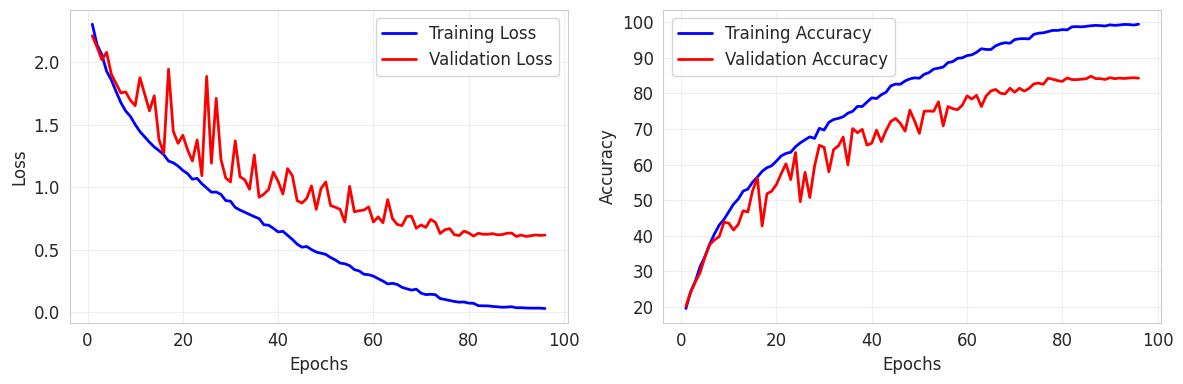

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.50.json

Starting training for data fraction = 75%

Training on 10 classes.
Training samples: 13743.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.68it/s]



 Epoch 1/100:
 Train Loss: 2.3689, Train Acc: 21.04%
 Val Loss: 2.1638, Val Acc: 21.21%
Saved best model (Val Acc: 21.21%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.75.pth.


Validation: 100%|██████████| 62/62 [00:07<00:00,  7.81it/s]



 Epoch 2/100:
 Train Loss: 2.1453, Train Acc: 23.63%
 Val Loss: 2.1341, Val Acc: 25.13%
Saved best model (Val Acc: 25.13%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_0.75.pth.


...

Validation: 100%|██████████| 62/62 [00:07<00:00,  7.82it/s]



 Epoch 57/100:
 Train Loss: 0.2877, Train Acc: 90.49%
 Val Loss: 0.7028, Val Acc: 79.93%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.69it/s]


 Epoch 58/100:
 Train Loss: 0.2663, Train Acc: 91.33%
 Val Loss: 0.6821, Val Acc: 80.75%
Early stopping triggered at epoch 58.
Training completed in 4359.13 seconds.



 Test Results: 
 Accuracy: 81.41%
 Precision: 81.93%
 Recall: 81.41%
 F1-score: 81.28%


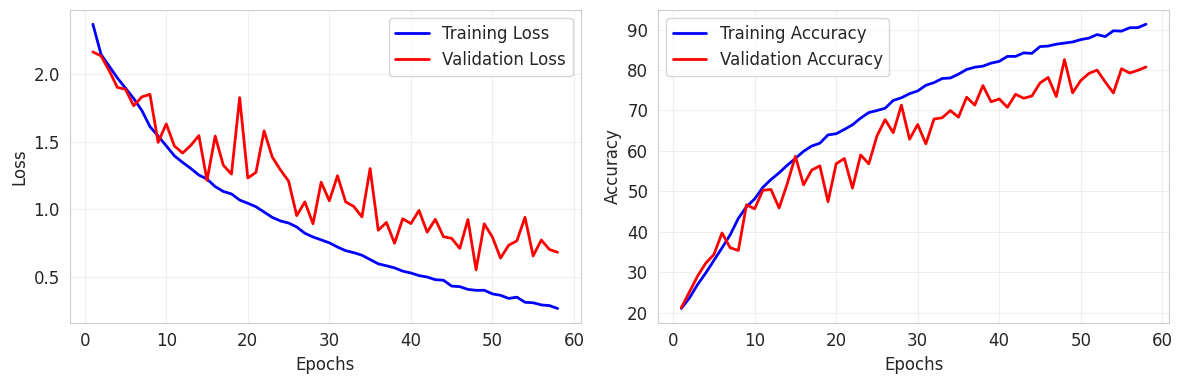

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.75.json

Starting training for data fraction = 100%

Training on 10 classes.
Training samples: 18325.
Validation samples: 3927.
Test samples: 3927.
Model ResNet-18 from scratch.
Parameters: 11,181,642


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.45it/s]



 Epoch 1/100:
 Train Loss: 2.2298, Train Acc: 20.63%
 Val Loss: 2.1272, Val Acc: 22.94%
Saved best model (Val Acc: 22.94%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_1.00.pth.


Validation: 100%|██████████| 62/62 [00:07<00:00,  7.87it/s]



 Epoch 2/100:
 Train Loss: 2.0925, Train Acc: 24.92%
 Val Loss: 2.0362, Val Acc: 27.30%
Saved best model (Val Acc: 27.30%) to /content/TOL506M_Final_Project/results/models/task1_scratch_best_fraction_1.00.pth.


...

Validation: 100%|██████████| 62/62 [00:08<00:00,  7.72it/s]



 Epoch 56/100:
 Train Loss: 0.1956, Train Acc: 93.51%
 Val Loss: 0.5387, Val Acc: 83.70%


Validation: 100%|██████████| 62/62 [00:08<00:00,  7.60it/s]


 Epoch 57/100:
 Train Loss: 0.1891, Train Acc: 93.81%
 Val Loss: 0.6349, Val Acc: 82.99%
Early stopping triggered at epoch 57.
Training completed in 5543.11 seconds.



 Test Results: 
 Accuracy: 84.87%
 Precision: 86.75%
 Recall: 84.87%
 F1-score: 85.27%


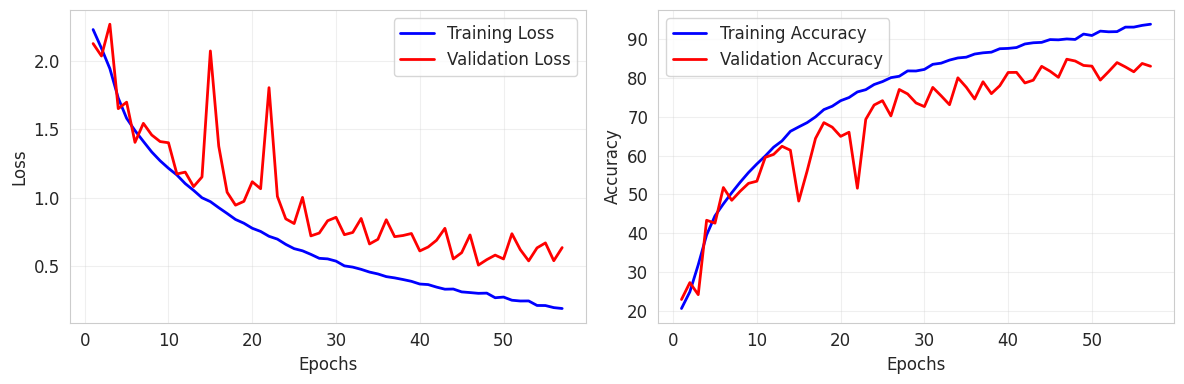

Saved metrics to /content/TOL506M_Final_Project/results/metrics/task1_scratch_results_1.00.json

Finished training for all fractions.


In [7]:
# Task 1: Train ResNet-18 from scratch for each data fraction
all_results = []

for frac in data_fractions:
  print(f"\nStarting training for data fraction = {frac*100:.0f}%\n")

  train_loader, val_loader, test_loader, num_classes = get_data_loaders(
        data_path=str(Config.DATA_PATH),
        batch_size=Config.BATCH_SIZE,
        num_workers=Config.NUM_WORKERS,
        train_split=Config.TRAIN_SPLIT,
        val_split=Config.VAL_SPLIT,
        test_split=Config.TEST_SPLIT,
        use_augmentation=Config.USE_AUGMENTATION,
        random_seed=random_seed,
        data_fraction=frac,
        fixed_indices=fixed,
        save_processed_root=str(Config.PROCESSED_DIR),
  )

  result = train_from_scratch(
        config=Config,
        data_fraction=frac,
        version_RestNet=18,
        save_model=True,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader
  )

  all_results.append(result)

print("\nFinished training for all fractions.")

In [8]:
# Save combined summary JSON
summary_path = Config.METRICS_DIR / f"task1_scratch_all_fractions_summary_{random_seed}.json"

with open(summary_path, "w") as f:
    json.dump(all_results, f, indent=4)

print(f"Saved combined summary to {summary_path}")

Saved combined summary to /content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary_640.json


In [9]:
from IPython.display import Image, display

for frac in data_fractions:
    plot_path = Config.PLOTS_DIR / f"task1_scratch_learning_curves_{frac:.2f}_{random_seed}.png"
    if plot_path.exists():
        print(f"\nLearning curves for fraction = {frac*100:.0f}%")
        display(Image(filename=str(plot_path)))
    else:
        print(f"Plot not found for fraction {frac:.2f}: {plot_path}")

Plot not found for fraction 0.10: /content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_0.10_640.png
Plot not found for fraction 0.25: /content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_0.25_640.png
Plot not found for fraction 0.50: /content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_0.50_640.png
Plot not found for fraction 0.75: /content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_0.75_640.png
Plot not found for fraction 1.00: /content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_1.00_640.png


In [10]:
!zip -r results_task1_640.zip /content/TOL506M_Final_Project/results/

  adding: content/TOL506M_Final_Project/results/ (stored 0%)
  adding: content/TOL506M_Final_Project/results/plots/ (stored 0%)
  adding: content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_0.10.png (deflated 11%)
  adding: content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_0.25.png (deflated 9%)
  adding: content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_1.00.png (deflated 9%)
  adding: content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_0.50.png (deflated 9%)
  adding: content/TOL506M_Final_Project/results/plots/task1_scratch_learning_curves_0.75.png (deflated 9%)
  adding: content/TOL506M_Final_Project/results/metrics/ (stored 0%)
  adding: content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.50.json (deflated 63%)
  adding: content/TOL506M_Final_Project/results/metrics/task1_scratch_results_0.75.json (deflated 61%)
  adding: content/TOL506M_Final_Project/results/metrics/task1

In [11]:
from google.colab import files
files.download("results_task1_640.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>